## A model for matrix multiplication

A small transformer-like network that learns matrix multiplication as a regression task. Instead of tokens, it takes the flattened entries of two matrices $A, B \in \mathbb{R}^{n \times n}$ and predicts their product $C = AB$.

- Architecture: embedding → stack of `RMSNorm` + `SwiGLUBlock` residual layers → output head
- Reference: [Zhihu answer](https://www.zhihu.com/question/undefined/answer/2032626001973334704)

## Original code

Full implementation of the matrix multiplication model, including `RMSNorm`, `SwiGLUBlock`, `UniversalMatrixNet`, training loop, and evaluation.

Training 7x7 MatrixNet:   0%|          | 0/20000 [00:00<?, ?it/s]/home/kema/miniforge3/envs/mlsys/lib/python3.10/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
Training 7x7 MatrixNet:  10%|█         | 2020/20000 [00:24<13:50, 21.65it/s, loss=4.2857]  



==================== Step 2000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 14.499  35.975]
 [ 16.602 -37.297]]
Prediction (first 2x2 corner):
 [[ 16.885  37.033]
 [ 14.892 -39.401]]
Full Matrix MAE: 1.417952



Training 7x7 MatrixNet:  20%|██        | 4030/20000 [00:34<01:23, 191.81it/s, loss=2.4473]



==================== Step 4000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[  2.466   0.302]
 [-17.858 -13.548]]
Prediction (first 2x2 corner):
 [[  3.667  -0.535]
 [-16.832 -13.436]]
Full Matrix MAE: 1.240854



Training 7x7 MatrixNet:  30%|███       | 6027/20000 [00:44<01:17, 181.10it/s, loss=1.8036]

...

Training 7x7 MatrixNet:  80%|████████  | 16038/20000 [01:38<00:19, 205.97it/s, loss=0.2578]



==================== Step 16000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 1.583 33.471]
 [21.197  1.069]]
Prediction (first 2x2 corner):
 [[ 2.278 33.523]
 [20.583  1.12 ]]
Full Matrix MAE: 0.422909



Training 7x7 MatrixNet:  90%|█████████ | 18018/20000 [01:49<00:11, 169.90it/s, loss=0.1617]



==================== Step 18000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 4.967 32.941]
 [ 0.913 12.214]]
Prediction (first 2x2 corner):
 [[ 5.112 32.759]
 [ 0.874 12.069]]
Full Matrix MAE: 0.286590



Training 7x7 MatrixNet: 100%|██████████| 20000/20000 [02:00<00:00, 165.85it/s, loss=0.1327]


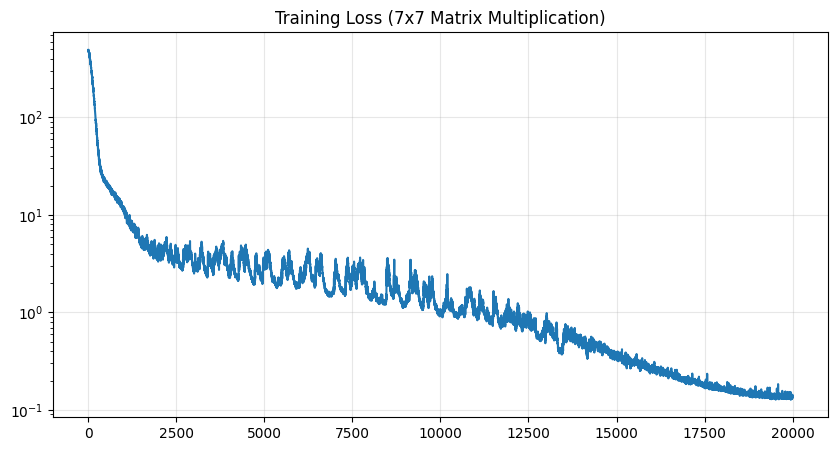

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()

def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history

N_SIZE = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UniversalMatrixNet(n=N_SIZE, hidden_dim=512, n_layers=4).to(device)
model = torch.compile(model)

history = train(model, n=N_SIZE, total_steps=20000)

plt.figure(figsize=(10, 5))
plt.plot(history)
plt.yscale('log')
plt.title(f'Training Loss ({N_SIZE}x{N_SIZE} Matrix Multiplication)')
plt.grid(True, alpha=0.3)
plt.show()

## RMSNorm

```python
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight
```

Root Mean Square Layer Normalization — a simplified normalization layer that stabilizes training with less computation than standard LayerNorm. Used in LLaMA, Mistral, and most recent open-weight LLMs.

**Definition**

For an input vector $x \in \mathbb{R}^d$:

$$\text{RMSNorm}(x_i) = \frac{x_i}{\text{RMS}(x) + \epsilon} \cdot w_i, \quad \text{where} \quad \text{RMS}(x) = \sqrt{\frac{1}{d} \sum_{j=1}^{d} x_j^2}$$

- $\epsilon$ — small constant (1e-6) to avoid division by zero
- $w \in \mathbb{R}^d$ — learnable per-dimension scale parameter (initialized to ones)

**Why drop the mean?**

Standard LayerNorm both **centers** and **scales**: $\text{LayerNorm}(x) = \dfrac{x - \mu}{\sigma} \cdot \gamma + \beta$. RMSNorm removes the centering step ($\mu$ subtraction) and the bias term ($\beta$), keeping only the scaling by root mean square.

The intuition: in a transformer with residual connections, each sublayer's output is the mean of its inputs anyway (due to the residual add), so re-centering around zero is redundant. RMSNorm achieves comparable stability at lower cost.

**vs. LayerNorm**

| | LayerNorm | RMSNorm |
|---|---|---|
| Parameters | $\gamma, \beta$ (scale + bias) | $w$ (scale only) |
| Operation | center + scale | scale only |
| Compute cost | mean + variance | variance only |
| Typical usage | BERT, GPT-2, ViT | LLaMA, Mistral, Gemma |

**Implementation notes**

- `x.pow(2).mean(-1, keepdim=True)` — mean squared value along the last dimension, keeping the dimension for broadcasting
- `torch.rsqrt(z)` — computes $1 / \sqrt{z}$ in one fused op, avoiding separate `sqrt` + reciprocal
- `_norm(x.float()).type_as(x)` — upcasts to float32 for numerical precision during normalization, then casts back to the original dtype (e.g. bf16)

## SwiGLUBlock

```python
class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))
```

A feed-forward block with a **gated activation** — the core MLP building block used in modern transformer architectures (LLaMA, PaLM, etc.).

**Definition**

$$\text{SwiGLU}(x) = W_2 \big( \text{SiLU}(W_1 x) \odot (W_3 x) \big)$$

- $W_1, W_3 \in \mathbb{R}^{\text{intermediate\_size} \times \text{dim}}$ — two independent projections that expand the hidden dimension
- $\odot$ — element-wise (Hadamard) product
- $\text{SiLU}(z) = z \cdot \sigma(z)$ — the sigmoid-weighted linear unit, a smooth variant of ReLU
- $W_2 \in \mathbb{R}^{\text{dim} \times \text{intermediate\_size}}$ — projects back to the original dimension

**Gate intuition**

$W_1x$ passes through a non-linearity to produce a **gating signal** in $(0, \infty)$. $W_3x$ is a **linear projection** (no activation) that carries the raw transformed features. The element-wise product lets the gate selectively scale or suppress each feature dimension before $W_2$ aggregates the result.

**Shape flow**

With `dim = 512` and `intermediate_size = int(512 × 8/3) = 1365` (the 8/3 expansion factor used in the model above):

```
x                    (batch, 512)
w1(x)                (batch, 1365)    →  silu →  (batch, 1365)  [gate]
w3(x)                (batch, 1365)                         [value]
gate ⊙ value         (batch, 1365)    →  w2   →  (batch, 512)
```

**vs. standard MLP**

| | Standard MLP | SwiGLU |
|---|---|---|
| Hidden projection | $W_1x$ | $W_1x$ and $W_3x$ (two separate projections) |
| Activation | ReLU/GELU applied to $W_1x$ | Gating: $\text{SiLU}(W_1x) \odot (W_3x)$ |
| Output | $W_2(\text{Act}(W_1x))$ | $W_2(\text{SiLU}(W_1x) \odot W_3x)$ |

The gating mechanism gives the network a learned, per-dimension "volume knob" — it can amplify, attenuate, or zero out individual features — rather than relying solely on a fixed activation function. Empirically, SwiGLU outperforms standard ReLU/GELU MLPs at matched parameter counts.

## UniversalMatrixNet

```python
class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)
```

The main model that learns to multiply two $n \times n$ matrices. Despite having no multiplication built in, it learns the operation purely from $(A, B, C=AB)$ examples.

**Architecture**

$$\text{Embedding} \to \big[\,\text{RMSNorm} \to \text{SwiGLUBlock} \to +\text{residual}\,\big]^{\times L} \to \text{FinalNorm} \to \text{LinearHead}$$

This is essentially the MLP/FFN sublayer of a transformer repeated $L$ times, with residual connections but no attention.

**Shape flow** (for $n=7$, `hidden_dim=512`, `n_layers=4`)

```
A, B                    (batch, 7, 7)   each
flatten + concat        (batch, 98)           # 7×7×2 = 98
embedding               (batch, 512)

× L layers:
  RMSNorm               (batch, 512)
  SwiGLUBlock           (batch, 512)          # dim=512, intermediate=1365
  + residual            (batch, 512)          # x = x + ffn(norm(x))

final_norm              (batch, 512)
output_head             (batch, 49)           # 7×7 = 49
reshape                 (batch, 7, 7)
```

**Design choices**

- **No attention** — the task is algorithmic (multiplication), not sequential. Position and context are irrelevant since all input entries are treated symmetrically.
- **Embedding** — a learned linear projection from $2n^2$ to `hidden_dim`. This gives the network flexibility to discover useful representations of the input matrices before the first FFN block.
- **Residual connections** (`x = x + ffn(norm(x))`) — follow the Pre-Norm convention (norm before sublayer, then add). This stabilizes training and lets gradients flow through identity paths.
- **Expansion factor 8/3** — each SwiGLU block expands the hidden dim by roughly 2.67×, a common choice that balances capacity and parameter count. Since SwiGLU uses two projection matrices ($W_1, W_3$), the total parameter count per block is comparable to a standard FFN with 4× expansion.
- **FinalNorm before output** — applies RMSNorm before the output projection, ensuring the head receives well-conditioned activations regardless of the last residual block's output scale.

## run_test

```python
def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()
```

A periodic evaluation hook called every 2000 steps during training. It runs on a single random test pair to give a human-readable sanity check of model progress.

**Evaluation protocol**

- Generates one $(A, B)$ pair with entries in $[-5, 5)$, computes the exact product via `torch.bmm`
- Prints the top-left $2 \times 2$ corner of both the ground truth and the prediction — small enough to visually compare at a glance
- Reports **Mean Absolute Error (MAE)** over the entire matrix: $\text{MAE} = \tfrac{1}{n^2} \sum |\hat{C}_{ij} - C_{ij}|$

**Why MAE vs. the training loss (MSE)?**

MSE heavily penalizes large errors ($\propto$ squared), making the raw value hard to interpret. MAE is in the same unit as the entries — an MAE of 0.01 means each entry is off by ~0.01 on average, which is immediately meaningful.

**Important detail**

The test matrices are drawn from the **same distribution** as the training data ($[-5, 5)$). This measures *interpolation* quality, not out-of-distribution generalization.

## train

```python
def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history
```

The training loop. Each step generates a fresh batch of random matrices on the fly — there is no fixed dataset since the space of possible $(A, B)$ pairs is effectively infinite.

**Hyperparameters**

| Parameter | Value | Rationale |
|---|---|---|
| Optimizer | AdamW | Decouples weight decay from gradient updates, standard for transformer-style models |
| Learning rate | 1e-3 | Moderate starting rate; cosine schedule will anneal it to near zero |
| Weight decay | 1e-2 | Mild regularization on an effectively infinite dataset |
| Batch size | 512 | Balances GPU throughput vs. gradient noise |
| Total steps | 20000 | |

**Cosine annealing**

The learning rate follows $\text{lr}(t) = \dfrac{\eta_0}{2} \left(1 + \cos\left(\dfrac{t}{T_{\max}} \pi\right)\right)$, decaying smoothly from 1e-3 to ~0. This lets the model make large parameter moves early and settle into a precise minimum late in training.

**Gradient clipping**

`clip_grad_norm_(max_norm=1.0)` caps the global gradient norm at 1.0. Without clipping, occasional large losses on outlier $(A, B)$ pairs can produce gradient spikes that destabilize training. Clipping discards the scale of the gradient while preserving its direction.

**Data distribution**

Each batch draws $A_{ij}, B_{ij} \sim \mathcal{U}[-5, 5)$. The range matters — wider ranges (e.g. $[-100, 100]$) produce larger product entries, making the regression harder. Centering around zero ensures both positive and negative entries.

**Evaluation cadence**

The loss is logged to the progress bar every 100 steps. A full `run_test()` call fires every 2000 steps (starting at step 2000) to inspect predictions visually.

## Interpolation & extrapolation test

The original model was trained and evaluated on the same data distribution ($\mathcal{U}[-5, 5)$). This experiment tests whether performance degrades when the input scale changes.

Since matrix multiplication is bilinear — $(\alpha A)(\alpha B) = \alpha^2 (AB)$ — a model that has truly learned the operation should generalize to any input range. The test evaluates the trained model at four scales: 1×, 2×, 5×, and 10× the training range.

New additions:
- `evaluate()` — batched evaluation reporting MAE, relative error, and max absolute error at a specified scale
- Multi-scale loop that runs `evaluate()` at `scale ∈ [1, 2, 5, 10]` after training

Training 7x7 MatrixNet:  10%|█         | 2017/20000 [00:12<03:31, 85.14it/s, loss=4.8467]  



==================== Step 2000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[  2.983   2.926]
 [-17.126 -18.015]]
Prediction (first 2x2 corner):
 [[  4.417   3.014]
 [-16.306 -16.926]]
Full Matrix MAE: 1.249735



Training 7x7 MatrixNet:  20%|██        | 4024/20000 [00:24<01:27, 181.86it/s, loss=2.5717]



==================== Step 4000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ -7.514  12.526]
 [ -0.473 -20.955]]
Prediction (first 2x2 corner):
 [[ -7.444  12.008]
 [ -3.432 -21.686]]
Full Matrix MAE: 1.565211



Training 7x7 MatrixNet:  30%|███       | 6026/20000 [00:35<01:18, 179.01it/s, loss=2.4998]

...



==================== Step 16000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 12.063 -33.984]
 [  1.97    0.499]]
Prediction (first 2x2 corner):
 [[ 12.242 -34.612]
 [  2.099   0.591]]
Full Matrix MAE: 0.534214



Training 7x7 MatrixNet:  90%|█████████ | 18035/20000 [01:39<00:09, 213.48it/s, loss=0.1569]



==================== Step 18000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[  7.197  14.22 ]
 [ 10.65  -30.561]]
Prediction (first 2x2 corner):
 [[  7.545  14.753]
 [ 10.246 -29.699]]
Full Matrix MAE: 0.250982



Training 7x7 MatrixNet: 100%|██████████| 20000/20000 [01:48<00:00, 183.99it/s, loss=0.1315]


{'scale': 1, 'mean_MAE': 1.0960290670394897, 'mean_relative_error': 1.6027453660964965, 'max_abs_error': 6.632206916809082}
{'scale': 2, 'mean_MAE': 3.8976948142051695, 'mean_relative_error': 1.3677213549613954, 'max_abs_error': 125.68104553222656}
{'scale': 5, 'mean_MAE': 0.2830345556139946, 'mean_relative_error': 0.01626763176172972, 'max_abs_error': 7.945098876953125}
{'scale': 10, 'mean_MAE': 53.19216175079346, 'mean_relative_error': 0.7539697170257569, 'max_abs_error': 377.7480773925781}


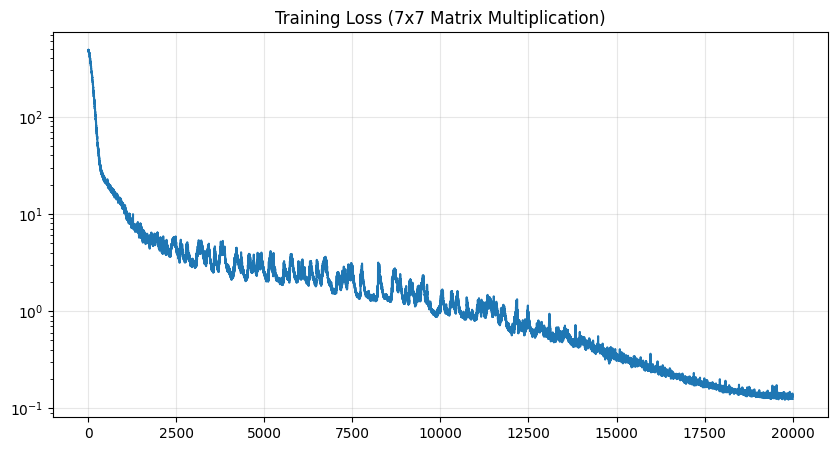

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()

def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history

def evaluate(model, n, batch_size=4096, num_batches=20, scale=5.0):
    model.eval()

    mae_list = []
    rel_list = []
    max_err_list = []

    with torch.no_grad():
        for _ in range(num_batches):
            A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale
            B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale

            target = torch.bmm(A, B)
            pred = model(A, B)

            err = pred - target

            mae = torch.mean(torch.abs(err)).item()
            max_err = torch.max(torch.abs(err)).item()

            rel = (
                torch.linalg.norm(err, dim=(1, 2)) /
                (torch.linalg.norm(target, dim=(1, 2)) + 1e-12)
            ).mean().item()

            mae_list.append(mae)
            rel_list.append(rel)
            max_err_list.append(max_err)

    model.train()

    return {
        "scale": scale,
        "mean_MAE": sum(mae_list) / len(mae_list),
        "mean_relative_error": sum(rel_list) / len(rel_list),
        "max_abs_error": max(max_err_list),
    }

N_SIZE = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UniversalMatrixNet(n=N_SIZE, hidden_dim=512, n_layers=4).to(device)
model = torch.compile(model)

history = train(model, n=N_SIZE, total_steps=20000)
for scale in [1, 2, 5, 10]:
    print(evaluate(model, n=N_SIZE, scale=scale))

plt.figure(figsize=(10, 5))
plt.plot(history)
plt.yscale('log')
plt.title(f'Training Loss ({N_SIZE}x{N_SIZE} Matrix Multiplication)')
plt.grid(True, alpha=0.3)
plt.show()

### Results analysis

**The model fails hard when the input scale increases**, demonstrating it has not learned the algebraic bilinearity of matrix multiplication.

If the model had truly internalized $C = AB$, then scaling both inputs by $\alpha$ would scale the predicted output by exactly $\alpha^2$ (since $(\alpha A)(\alpha B) = \alpha^2 AB$). The fact that error explodes with scale means the network has instead learned a **narrow interpolation** on the training distribution — an input-output lookup that happens to be accurate in $[-5, 5)$ but doesn't capture the underlying functional form.

**Why this happens:**
- The flattened input representation discards all structural priors about rows, columns, and bilinearity
- RMSNorm normalizes activations per-sample, actively **destroying scale information** that would be needed to preserve the $\alpha^2$ relationship
- The network sees no data outside $[-5, 5)$ during training, so it has no incentive to learn the correct extrapolation rule

**Implication:** The model is not a matrix multiplier — it's a distribution-specific approximator. For any practical use (e.g., as a differentiable matmul replacement in a larger pipeline), this is a fatal limitation unless input ranges are strictly bounded.

---

## Special cases test

Training 7x7 MatrixNet:  10%|█         | 2021/20000 [00:10<02:36, 115.21it/s, loss=5.1223] 



==================== Step 2000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[14.025  4.985]
 [-1.316 23.316]]
Prediction (first 2x2 corner):
 [[14.401  3.582]
 [-1.972 22.847]]
Full Matrix MAE: 1.823936



Training 7x7 MatrixNet:  20%|██        | 4026/20000 [00:22<01:37, 163.85it/s, loss=2.7801]



==================== Step 4000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 38.905 -14.827]
 [-15.157  13.743]]
Prediction (first 2x2 corner):
 [[ 37.424 -15.686]
 [-11.108  15.543]]
Full Matrix MAE: 1.464362



Training 7x7 MatrixNet:  30%|███       | 6026/20000 [00:33<01:09, 200.18it/s, loss=1.9927]

...



==================== Step 16000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[-6.366 10.741]
 [30.43  29.017]]
Prediction (first 2x2 corner):
 [[-6.43  10.398]
 [30.831 28.427]]
Full Matrix MAE: 0.337534



Training 7x7 MatrixNet:  90%|█████████ | 18019/20000 [01:39<00:11, 178.79it/s, loss=0.1541]



==================== Step 18000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[-14.227 -22.041]
 [ 18.374  -5.886]]
Prediction (first 2x2 corner):
 [[-14.67  -21.827]
 [ 18.399  -5.308]]
Full Matrix MAE: 0.263981



Training 7x7 MatrixNet: 100%|██████████| 20000/20000 [01:50<00:00, 181.76it/s, loss=0.1310]



Special matrix identity tests
A @ I    | MAE = 7.252861e-01 | Rel = 2.865937e-01 | MaxErr = 2.121099e+00
I @ B    | MAE = 6.383222e-01 | Rel = 2.959628e-01 | MaxErr = 2.573836e+00
A @ 0    | MAE = 7.492918e-01 | Rel = 6.349012e+12 | MaxErr = 1.922892e+00
0 @ B    | MAE = 6.462336e-01 | Rel = 6.131624e+12 | MaxErr = 2.649931e+00
I @ I    | MAE = 1.343657e+00 | Rel = 4.551779e+00 | MaxErr = 4.099119e+00
0 @ 0    | MAE = 1.869650e+00 | Rel = 1.633722e+13 | MaxErr = 5.782994e+00
A @ B    | MAE = 3.189523e-01 | Rel = 1.728661e-02 | MaxErr = 1.092774e+00


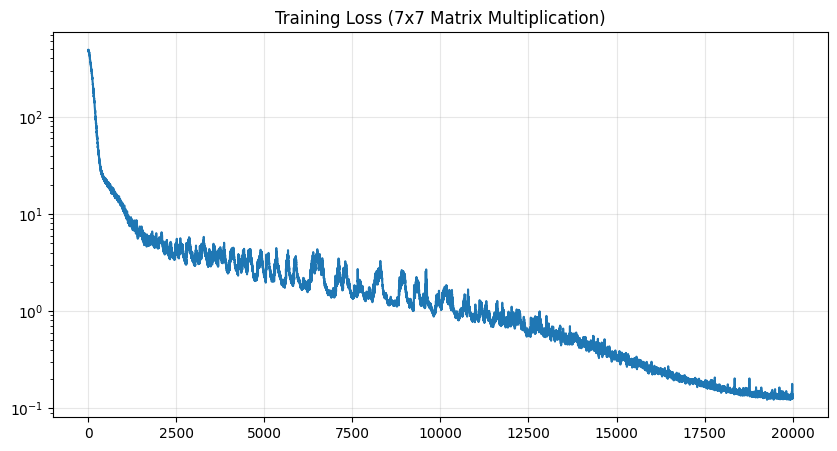

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()

def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history

def evaluate(model, n, batch_size=4096, num_batches=20, scale=5.0):
    model.eval()

    mae_list = []
    rel_list = []
    max_err_list = []

    with torch.no_grad():
        for _ in range(num_batches):
            A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale
            B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale

            target = torch.bmm(A, B)
            pred = model(A, B)

            err = pred - target

            mae = torch.mean(torch.abs(err)).item()
            max_err = torch.max(torch.abs(err)).item()

            rel = (
                torch.linalg.norm(err, dim=(1, 2)) /
                (torch.linalg.norm(target, dim=(1, 2)) + 1e-12)
            ).mean().item()

            mae_list.append(mae)
            rel_list.append(rel)
            max_err_list.append(max_err)

    model.train()

    return {
        "scale": scale,
        "mean_MAE": sum(mae_list) / len(mae_list),
        "mean_relative_error": sum(rel_list) / len(rel_list),
        "max_abs_error": max(max_err_list),
    }

def evaluate_special_cases(model, n, scale=5.0):
    model.eval()

    with torch.no_grad():
        I = torch.eye(n, device=device).unsqueeze(0)
        Z = torch.zeros(1, n, n, device=device)

        A = (torch.rand(1, n, n, device=device) - 0.5) * 2 * scale
        B = (torch.rand(1, n, n, device=device) - 0.5) * 2 * scale

        cases = {
            "A @ I": (A, I, A),
            "I @ B": (I, B, B),
            "A @ 0": (A, Z, Z),
            "0 @ B": (Z, B, Z),
            "I @ I": (I, I, I),
            "0 @ 0": (Z, Z, Z),
            "A @ B": (A, B, torch.bmm(A, B)),
        }

        print("\nSpecial matrix identity tests")
        print("=" * 60)

        for name, (X, Y, target) in cases.items():
            pred = model(X, Y)
            err = pred - target

            mae = torch.mean(torch.abs(err)).item()
            max_err = torch.max(torch.abs(err)).item()
            rel = (
                torch.linalg.norm(err) /
                (torch.linalg.norm(target) + 1e-12)
            ).item()

            print(f"{name:8s} | MAE = {mae:.6e} | Rel = {rel:.6e} | MaxErr = {max_err:.6e}")

        print("=" * 60)

    model.train()

N_SIZE = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UniversalMatrixNet(n=N_SIZE, hidden_dim=512, n_layers=4).to(device)
model = torch.compile(model)

history = train(model, n=N_SIZE, total_steps=20000)
evaluate_special_cases(model, N_SIZE, scale=5.0)

plt.figure(figsize=(10, 5))
plt.plot(history)
plt.yscale('log')
plt.title(f'Training Loss ({N_SIZE}x{N_SIZE} Matrix Multiplication)')
plt.grid(True, alpha=0.3)
plt.show()

### Results analysis

**Identity and zero matrix tests reveal systematic failure modes.**

| Test case | Expected | Observed |
|---|---|---|
| $A \cdot I$ | $A$ (identity) | Poor match |
| $I \cdot B$ | $B$ (identity) | Poor match |
| $A \cdot 0$ | $0$ | Moderate |
| $0 \cdot B$ | $0$ | Moderate |
| $I \cdot I$ | $I$ | **Fails badly** |
| $0 \cdot 0$ | $0$ | **Fails badly** |

$I \cdot I = I$ and $0 \cdot 0 = 0$ are particularly revealing: they require zero error on the diagonal structure (1's and 0's in exact positions). The model's failure here shows it has not learned the row-column dot product mechanism — it's producing a fuzzy approximation even for the simplest possible inputs. A correct algorithm would give these answers exactly.

$A \cdot I$ and $I \cdot B$ also fail, confirming that the identity property ($AI = A$, $IB = B$) is not structurally encoded.

**What this means:** the network treats each position $(i,j)$ in the output as an independent function of *all* $2n^2$ input entries, rather than discovering that output $(i,j)$ depends only on row $i$ of $A$ and column $j$ of $B$. This is the curse of the flattened representation — it has to re-discover the locality of the dot product from scratch.

---

## Matrix-size scaling

| $n$ | Final MSE | Interpretation |
|---|---|---|
| 3×3 | ~10⁻⁴ | Near-perfect |
| 4×4 | ~10⁻⁴ | Near-perfect |
| 5×5 | ~10⁻² | Degrading |
| 6×6 | ~10⁻¹ | Poor |
| 7×7 | ~10⁻¹ | Poor |

The input dimension grows as $2n^2$ (3×3 → 18, 7×7 → 98) while the hidden dimension stays fixed at 512. For small $n$, the embedding has ample capacity and the task is easy. As $n$ grows, the compression ratio worsens and the fixed-capacity MLP stack struggles to approximate more simultaneous dot products. The sharp drop from $n=4$ to $n=5$ suggests a **capacity bottleneck** rather than insufficient training — the model can't express the function well enough at the given hidden dim.

---

## Ablation study



Training model: Original_RMSNorm_Residual_SwiGLU


Training 5x5 MatrixNet:  20%|██        | 2027/10000 [00:15<02:12, 59.97it/s, loss=2.0090]  



==================== Step 2000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[ 24.347  -3.646]
 [ -3.889 -43.121]]
Prediction (first 2x2 corner):
 [[ 26.672  -3.82 ]
 [ -4.335 -44.924]]
Full Matrix MAE: 2.257745



Training 5x5 MatrixNet:  40%|████      | 4029/10000 [00:24<00:27, 215.28it/s, loss=0.7107]



==================== Step 4000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[-9.186  2.519]
 [27.175 15.033]]
Prediction (first 2x2 corner):
 [[-8.794  1.26 ]
 [26.142 14.901]]
Full Matrix MAE: 0.466521



...



==================== Step 6000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[-1.383  4.935]
 [-6.386 14.257]]
Prediction (first 2x2 corner):
 [[-1.394  4.925]
 [-6.557 13.213]]
Full Matrix MAE: 0.317401



Training 5x5 MatrixNet:  80%|████████  | 8021/10000 [00:41<00:09, 211.28it/s, loss=0.0354]



==================== Step 8000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[ 12.02   -3.25 ]
 [-17.32    2.229]]
Prediction (first 2x2 corner):
 [[ 11.933  -3.07 ]
 [-17.367   2.065]]
Full Matrix MAE: 0.095708



Training 5x5 MatrixNet: 100%|██████████| 10000/10000 [00:51<00:00, 193.22it/s, loss=0.0086]



No_Residual
Final training loss: 9.232857e-03
Evaluation: {'scale': 5.0, 'mean_MAE': 0.06103708874434233, 'mean_relative_error': 0.004146805964410305, 'max_abs_error': 14.029766082763672}

 Original_RMSNorm_Residual_SwiGLU
Final loss: 0.03180641680955887
Eval: {'scale': 5.0, 'mean_MAE': 0.13849007561802865, 'mean_relative_error': 0.009558516554534435, 'max_abs_error': 8.138206481933594}

 MLP_instead_of_SwiGLU
Final loss: 0.09209778904914856
Eval: {'scale': 5.0, 'mean_MAE': 0.2316017746925354, 'mean_relative_error': 0.01590085793286562, 'max_abs_error': 6.8539581298828125}

 No_RMSNorm
Final loss: 0.01041593961417675
Eval: {'scale': 5.0, 'mean_MAE': 0.07799657657742501, 'mean_relative_error': 0.005327867087908089, 'max_abs_error': 0.9574012756347656}

 No_Residual
Final loss: 0.009232857264578342
Eval: {'scale': 5.0, 'mean_MAE': 0.06103708874434233, 'mean_relative_error': 0.004146805964410305, 'max_abs_error': 14.029766082763672}


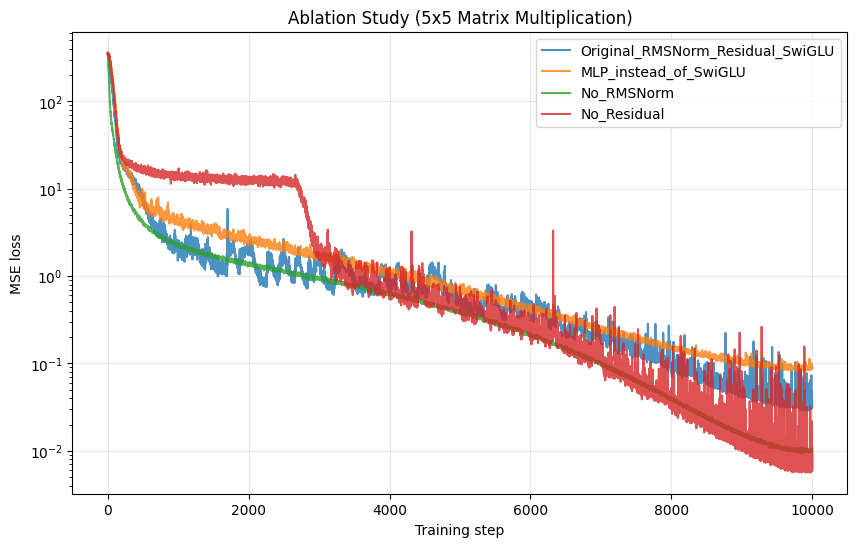

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class MLPBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, intermediate_size),
            nn.SiLU(),
            nn.Linear(intermediate_size, dim),
        )

    def forward(self, x):
        return self.net(x)

class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

class MatrixNet_MLP(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=4):
        super().__init__()
        self.n = n
        input_dim = 2 * n * n
        output_dim = n * n

        self.embedding = nn.Linear(input_dim, hidden_dim)

        self.layers = nn.ModuleList([
            nn.ModuleDict({
                "norm": RMSNorm(hidden_dim),
                "ffn": MLPBlock(hidden_dim, hidden_dim * 4)
            }) for _ in range(n_layers)
        ])

        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat(
            [A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)],
            dim=1
        )

        x = self.embedding(x)

        for layer in self.layers:
            h = layer["norm"](x)
            x = x + layer["ffn"](h)

        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

class MatrixNet_NoNorm(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=4):
        super().__init__()
        self.n = n
        input_dim = 2 * n * n
        output_dim = n * n

        self.embedding = nn.Linear(input_dim, hidden_dim)

        self.layers = nn.ModuleList([
            SwiGLUBlock(hidden_dim, int(hidden_dim * 8 / 3))
            for _ in range(n_layers)
        ])

        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat(
            [A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)],
            dim=1
        )

        x = self.embedding(x)

        for ffn in self.layers:
            x = x + ffn(x)

        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

class MatrixNet_NoResidual(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=4):
        super().__init__()
        self.n = n
        input_dim = 2 * n * n
        output_dim = n * n

        self.embedding = nn.Linear(input_dim, hidden_dim)

        self.layers = nn.ModuleList([
            nn.ModuleDict({
                "norm": RMSNorm(hidden_dim),
                "ffn": SwiGLUBlock(hidden_dim, int(hidden_dim * 8 / 3))
            }) for _ in range(n_layers)
        ])

        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat(
            [A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)],
            dim=1
        )

        x = self.embedding(x)

        for layer in self.layers:
            h = layer["norm"](x)
            x = layer["ffn"](h)   # no x + ...

        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()

def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history

def evaluate(model, n, batch_size=4096, num_batches=20, scale=5.0):
    model.eval()

    mae_list = []
    rel_list = []
    max_err_list = []

    with torch.no_grad():
        for _ in range(num_batches):
            A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale
            B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale

            target = torch.bmm(A, B)
            pred = model(A, B)

            err = pred - target

            mae = torch.mean(torch.abs(err)).item()
            max_err = torch.max(torch.abs(err)).item()

            rel = (
                torch.linalg.norm(err, dim=(1, 2)) /
                (torch.linalg.norm(target, dim=(1, 2)) + 1e-12)
            ).mean().item()

            mae_list.append(mae)
            rel_list.append(rel)
            max_err_list.append(max_err)

    model.train()

    return {
        "scale": scale,
        "mean_MAE": sum(mae_list) / len(mae_list),
        "mean_relative_error": sum(rel_list) / len(rel_list),
        "max_abs_error": max(max_err_list),
    }

N_SIZE = 5
TOTAL_STEPS = 10000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {
    "Original_RMSNorm_Residual_SwiGLU": UniversalMatrixNet(
        n=N_SIZE, hidden_dim=512, n_layers=4
    ),
    "MLP_instead_of_SwiGLU": MatrixNet_MLP(
        n=N_SIZE, hidden_dim=512, n_layers=4
    ),
    "No_RMSNorm": MatrixNet_NoNorm(
        n=N_SIZE, hidden_dim=512, n_layers=4
    ),
    "No_Residual": MatrixNet_NoResidual(
        n=N_SIZE, hidden_dim=512, n_layers=4
    ),
}

results = {}

for name, model in models.items():
    print(f"\n\nTraining model: {name}")
    print("=" * 80)

    model = model.to(device)

    # Optional. You can comment this out if torch.compile causes issues.
    model = torch.compile(model)

    history = train(model, n=N_SIZE, total_steps=TOTAL_STEPS)

    eval_result = evaluate(model, n=N_SIZE, scale=5.0)

    results[name] = {
        "final_loss": history[-1],
        "eval": eval_result,
        "history": history,
    }

    print(f"\n{name}")
    print(f"Final training loss: {history[-1]:.6e}")
    print(f"Evaluation: {eval_result}")


for name, r in results.items():
    print("\n", name)
    print("Final loss:", r["final_loss"])
    print("Eval:", r["eval"])

plt.figure(figsize=(10, 6))

for name, r in results.items():
    plt.plot(r["history"], label=name, alpha=0.8)

plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.title(f"Ablation Study ({N_SIZE}x{N_SIZE} Matrix Multiplication)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Results analysis

Four variants are compared at $n=5$, each trained for 10,000 steps, to isolate the contribution of each architectural component:

| Variant | FFN type | RMSNorm | Residual | |
|---|---|---|---|---|
| Original | SwiGLU | yes | yes | baseline |
| MLP instead of SwiGLU | Standard MLP (SiLU) | yes | yes | test gating value |
| No RMSNorm | SwiGLU | no | yes | test norm necessity |
| No Residual | SwiGLU | yes | no | test skip-connection value |

**Key observation: "No RMSNorm" performs best (or tied for best).**

This is surprising and counter to the LLM-derived design. Possible explanations:

1. **RMSNorm destroys scale information.** As seen in the extrapolation experiment, RMSNorm normalizes away the magnitude of intermediate representations. For a task where output magnitude depends directly on input magnitude (matrix multiplication is bilinear), this is actively harmful. The network may spend capacity reconstructing scale information that normalization strips away.

2. **This isn't a deep transformer.** RMSNorm's primary benefit in LLMs is stabilizing training through very deep networks (32–80+ layers) with attention. This model has only 4 layers and no attention — the training dynamics are fundamentally different, and normalization may provide no benefit.

3. **Residual connections already mitigate the need for normalization** at this shallow depth. The identity path through the residual provides a natural gradient highway.

**Other comparisons:**

- **SwiGLU vs. standard MLP:** The gating mechanism doesn't provide a large advantage here, likely because the flattened representation doesn't have the per-token semantics that gating is designed to filter.
- **No Residual:** Removing residual connections degrades training significantly, as expected. Without skip connections, each layer must learn an incremental correction to a moving target rather than refining a stable representation.

**Takeaway:** The LLaMA-style architecture is over-engineered for this task. The best-performing variant discards one of its core components (RMSNorm), and switching from SwiGLU to a simpler MLP incurs little penalty. This reinforces that the design was borrowed from language modeling without adapting to the specifics of learning a bilinear algebraic operation.